# ABSA and Emotion Recognition

**Gudsky Research Foundation  |  Research Intake 2026  |  Day 23**
*Module: Sentiment and Semantics*

This notebook implements the two principal tasks from the Day 23 compendium:

1. **Aspect-Based Sentiment Analysis (ABSA)** -- classifying sentiment at the level of a named
   aspect within a sentence, using both a BERT sentence-pair classifier (for ASC) and a
   generative T5 approach (for end-to-end triplet extraction).

2. **Emotion Recognition** -- multi-label classification of text into six basic emotion
   categories using the `dair-ai/emotion` dataset and a fine-tuned BERT model.

**Runtime:** Set `Runtime > Change runtime type > Hardware accelerator > T4 GPU`.


## 1  Environment Setup

In [1]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    device = torch.device("cpu")
    print("No GPU detected. Sections 3 and 5 will be slow on CPU.")


GPU: Tesla T4
VRAM: 15.6 GB


In [2]:
!pip uninstall -y -q huggingface_hub
!pip install -q "huggingface_hub>=0.34.0,<1.0"
!pip install -q -U transformers datasets accelerate
!pip install -q matplotlib seaborn scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 16.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 5.13.1 requires huggingface-hub<2.0,>=1.5.0, but you have huggingface-hub 0.36.2 which is incompatible.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 80.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.9/771.9 kB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 16.8 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from datasets import load_dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           T5ForConditionalGeneration, T5Tokenizer,
                           TrainingArguments, Trainer, DataCollatorWithPadding)
from sklearn.metrics import accuracy_score, f1_score, classification_report

def make_training_args(**kwargs):
    '''Build TrainingArguments handling the eval_strategy / evaluation_strategy rename
    across transformers versions.'''
    strategy = kwargs.pop("eval_strategy", "epoch")
    try:
        return TrainingArguments(eval_strategy=strategy, **kwargs)
    except TypeError:
        return TrainingArguments(evaluation_strategy=strategy, **kwargs)

def compute_metrics_binary(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, preds),
            "f1": f1_score(labels, preds, average="weighted")}

print("Imports complete.")


Imports complete.


## 2  ABSA Fundamentals: Task Definitions

Aspect-Based Sentiment Analysis decomposes sentence-level sentiment into aspect-polarity pairs.
The four standard sub-tasks (from the Day 23 compendium, Section 1.2) are:

| Sub-task | Input | Output |
|---|---|---|
| ATE | Sentence | Aspect term spans |
| ASC | Sentence + aspect term | Polarity (pos / neg / neu) |
| ASTE | Sentence | (aspect, opinion, polarity) triplets |
| ASQP | Sentence | (category, term, opinion, polarity) quads |

This notebook focuses on **ASC** (the most commonly deployed sub-task in production) and a
demonstration of the **generative ABSA** approach for ASTE.


In [4]:
# Illustrative ABSA examples from the SemEval 2014 restaurant domain.
# In a production system these would be loaded from the annotated SemEval XML files.
# Here we embed a small representative sample to demonstrate the ASC formulation.

absa_examples = [
    # (sentence, aspect_term, true_polarity)
    ("The food was absolutely delicious.",                   "food",         "positive"),
    ("The service was painfully slow.",                      "service",      "negative"),
    ("The prices are reasonable for the area.",              "prices",       "positive"),
    ("The pasta was average but the pizza was outstanding.", "pasta",        "negative"),
    ("The pasta was average but the pizza was outstanding.", "pizza",        "positive"),
    ("Ambience is nice but nothing special.",                "Ambience",     "neutral"),
    ("I would not recommend the fish -- totally overcooked.","fish",         "negative"),
    ("The staff were friendly and attentive throughout.",    "staff",        "positive"),
    ("The waiting time was unacceptably long.",              "waiting time", "negative"),
    ("The cocktails are a highlight of any visit.",          "cocktails",    "positive"),
]

df_absa = pd.DataFrame(absa_examples, columns=["sentence", "aspect", "polarity"])
print(df_absa.to_string(index=False))


                                             sentence       aspect polarity
                   The food was absolutely delicious.         food positive
                      The service was painfully slow.      service negative
              The prices are reasonable for the area.       prices positive
 The pasta was average but the pizza was outstanding.        pasta negative
 The pasta was average but the pizza was outstanding.        pizza positive
                Ambience is nice but nothing special.     Ambience  neutral
I would not recommend the fish -- totally overcooked.         fish negative
    The staff were friendly and attentive throughout.        staff positive
              The waiting time was unacceptably long. waiting time negative
          The cocktails are a highlight of any visit.    cocktails positive


## 3  ASC: BERT Sentence-Pair Classifier

The BERT-based approach to Aspect Sentiment Classification (ASC) encodes the sentence and the
aspect term as a sentence pair, separated by the [SEP] token:

    [CLS] sentence [SEP] aspect_term [SEP]

The model attends to the aspect term while encoding the sentence, enabling it to focus on the
opinion words relevant to that specific aspect.  This formulation is analogous to how BERT handles
question answering and NLI.

We use the SST-2 fine-tuned checkpoint as a starting point and reformat the ABSA examples into
a two-class (positive / negative) demonstration.  In a full production system you would fine-tune
on a larger annotated ABSA corpus (SemEval 2014 Task 4 is the standard benchmark).


In [5]:
# Build a sentence-pair input for each ABSA example.
# Format: tokenizer(sentence, aspect_term) produces:
#   [CLS] sentence tokens [SEP] aspect tokens [SEP]
# The [CLS] representation is used for polarity classification.

ABSA_MODEL = "bert-base-uncased"
absa_tokenizer = AutoTokenizer.from_pretrained(ABSA_MODEL)

# Demonstrate the tokenisation format
example_sentence = "The food was absolutely delicious."
example_aspect   = "food"
encoding = absa_tokenizer(example_sentence, example_aspect,
                           return_tensors="pt", truncation=True, max_length=128)

decoded = absa_tokenizer.convert_ids_to_tokens(encoding["input_ids"][0])
print("Token sequence for sentence-pair ASC input:")
print(" ".join(decoded))
print()
print("token_type_ids (0 = sentence A, 1 = sentence B):")
print(encoding["token_type_ids"][0].numpy().tolist())


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Token sequence for sentence-pair ASC input:
[CLS] the food was absolutely delicious . [SEP] food [SEP]

token_type_ids (0 = sentence A, 1 = sentence B):
[0, 0, 0, 0, 0, 0, 0, 0, 1, 1]


In [6]:
# Build a zero-shot ASC scorer using a model pre-trained on NLI.
# We frame the task as: does the sentence entail that the aspect sentiment is positive?
# This requires no ABSA-specific training data and illustrates the NLI-as-classifier pattern
# from Day 24, Section 4.3.

from transformers import pipeline as hf_pipeline

# facebook/bart-large-mnli is an NLI model fine-tuned on MultiNLI.
nli_pipe = hf_pipeline("zero-shot-classification",
                        model="facebook/bart-large-mnli",
                        device=0 if torch.cuda.is_available() else -1)

def asc_zero_shot(sentence, aspect):
    '''Classify aspect sentiment using zero-shot NLI.

    Parameters
    ----------
    sentence : str
        The source review sentence.
    aspect : str
        The aspect term whose sentiment is to be classified.

    Returns
    -------
    str
        Predicted polarity: "positive", "negative", or "neutral".
    float
        Confidence score for the predicted label.
    '''
    # Construct a combined input so the model knows which aspect we are asking about
    combined = f"Regarding {aspect}: {sentence}"
    result = nli_pipe(combined,
                      candidate_labels=["positive sentiment", "negative sentiment",
                                        "neutral sentiment"],
                      multi_label=False)
    label = result["labels"][0].split()[0]   # "positive", "negative", or "neutral"
    score = result["scores"][0]
    return label, score

print("Running zero-shot ASC on the illustrative examples...")
print(f"{'Sentence':<50}  {'Aspect':<14}  {'True':<9}  {'Pred':<9}  Conf")
print("-" * 100)
correct = 0
for _, row in df_absa.iterrows():
    pred, conf = asc_zero_shot(row["sentence"], row["aspect"])
    match = pred == row["polarity"]
    correct += int(match)
    flag = "" if match else " <--"
    print(f"{row['sentence'][:49]:<50}  {row['aspect']:<14}  {row['polarity']:<9}  {pred:<9}  {conf:.2f}{flag}")

print("Accuracy on illustrative examples:", correct, "/", len(df_absa))


config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.63GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Running zero-shot ASC on the illustrative examples...
Sentence                                            Aspect          True       Pred       Conf
----------------------------------------------------------------------------------------------------
The food was absolutely delicious.                  food            positive   positive   0.98
The service was painfully slow.                     service         negative   negative   0.97
The prices are reasonable for the area.             prices          positive   positive   0.73
The pasta was average but the pizza was outstandi   pasta           negative   negative   0.41
The pasta was average but the pizza was outstandi   pizza           positive   positive   0.96
Ambience is nice but nothing special.               Ambience        neutral    neutral    0.88
I would not recommend the fish -- totally overcoo   fish            negative   negative   0.99
The staff were friendly and attentive throughout.   staff           positive   positi

## 4  Generative ABSA with T5

The generative approach (GAS -- Generative ABSA Solver, Zhang et al. 2021) reformulates ABSA as
a conditional text generation problem.  Given a sentence, T5 is trained to produce a structured
output string encoding all aspect-sentiment triplets:

    Input:  "absa triplet: The battery life is poor but the camera is superb."
    Output: "(battery life, poor, negative) | (camera, superb, positive)"

This unified formulation handles ATE, ASC, and ASTE in a single model with a single training
objective and no task-specific architectural modifications.

The cell below demonstrates the inference format with a pre-trained T5-base checkpoint.  For
production use you would fine-tune T5 on SemEval-annotated (sentence, structured_output) pairs.


In [7]:
# Demonstrate the GAS inference format using T5-base.
# T5-base has not been fine-tuned on ABSA here, so the outputs will not be correct --
# this cell illustrates the input/output format and decoding setup.
# Replace the checkpoint path with a fine-tuned ABSA checkpoint for real predictions.

t5_model_name = "t5-base"
t5_tokenizer  = T5Tokenizer.from_pretrained(t5_model_name)
t5_model      = T5ForConditionalGeneration.from_pretrained(t5_model_name).to(device)
t5_model.eval()

def generate_absa_triplets(sentence, max_new_tokens=80):
    '''Generate ABSA triplets from a review sentence using T5.

    Parameters
    ----------
    sentence : str
        The review sentence to analyse.
    max_new_tokens : int
        Maximum number of tokens to generate in the output string.
        80 tokens is sufficient for sentences with up to 4-5 triplets.

    Returns
    -------
    str
        Generated structured output string.
    '''
    # The "absa triplet:" prefix is the task identifier T5 was pre-trained to understand
    input_text = f"absa triplet: {sentence}"
    inputs = t5_tokenizer(input_text, return_tensors="pt",
                           truncation=True, max_length=128).to(device)

    with torch.no_grad():
        output_ids = t5_model.generate(
            inputs["input_ids"],
            max_new_tokens=max_new_tokens,
            num_beams=4,            # beam search: maintains 4 candidate sequences
            early_stopping=True,    # stop when all beams reach [EOS]
        )

    return t5_tokenizer.decode(output_ids[0], skip_special_tokens=True)

# Illustrate the expected input/output format
print("Generative ABSA -- expected output format (requires fine-tuned checkpoint):")
print()
expected = [
    ("The battery life is poor but the camera is superb.",
     "(battery life, poor, negative) | (camera, superb, positive)"),
    ("Excellent food at a very fair price.",
     "(food, excellent, positive) | (price, fair, positive)"),
    ("Service was slow but the staff were polite.",
     "(service, slow, negative) | (staff, polite, positive)"),
]
for sentence, target in expected:
    print(f"  Input : {sentence}")
    print(f"  Target: {target}")
    print()


spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  892MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Generative ABSA -- expected output format (requires fine-tuned checkpoint):

  Input : The battery life is poor but the camera is superb.
  Target: (battery life, poor, negative) | (camera, superb, positive)

  Input : Excellent food at a very fair price.
  Target: (food, excellent, positive) | (price, fair, positive)

  Input : Service was slow but the staff were polite.
  Target: (service, slow, negative) | (staff, polite, positive)



In [8]:
# Show what the fine-tuning data format looks like.
# In a full training run, each example is:
#   input_ids  = tokenizer("absa triplet: " + sentence)
#   labels     = tokenizer(structured_triplet_string)

def prepare_absa_example(sentence, triplet_string, tokenizer, max_src=128, max_tgt=96):
    '''Tokenise a single ABSA training example.

    Parameters
    ----------
    sentence : str
        Source review sentence.
    triplet_string : str
        Target structured output, e.g. "(food, delicious, positive)".
    tokenizer : T5Tokenizer
        Tokeniser instance.
    max_src : int
        Maximum source sequence length in tokens.
    max_tgt : int
        Maximum target sequence length in tokens.  96 is sufficient for up to 5 triplets.

    Returns
    -------
    dict
        Dictionary with input_ids, attention_mask, and labels tensors.
    '''
    src = tokenizer(f"absa triplet: {sentence}",
                    truncation=True, max_length=max_src, return_tensors="pt")
    tgt = tokenizer(triplet_string,
                    truncation=True, max_length=max_tgt, return_tensors="pt")
    # T5 uses -100 as the padding token in labels (ignored in loss computation)
    labels = tgt["input_ids"].clone()
    labels[labels == tokenizer.pad_token_id] = -100
    return {"input_ids": src["input_ids"], "labels": labels}

ex = prepare_absa_example(
    "The food was absolutely delicious.",
    "(food, delicious, positive)",
    t5_tokenizer,
)
print("input_ids shape :", ex["input_ids"].shape)
print("labels shape    :", ex["labels"].shape)
print("Decoded input   :", t5_tokenizer.decode(ex["input_ids"][0], skip_special_tokens=True))
print("Decoded target  :", t5_tokenizer.decode(
    [t for t in ex["labels"][0] if t != -100], skip_special_tokens=True))


input_ids shape : torch.Size([1, 13])
labels shape    : torch.Size([1, 8])
Decoded input   : absa triplet: The food was absolutely delicious.
Decoded target  : (food, delicious, positive)


## 5  Emotion Recognition

We fine-tune BERT on the `dair-ai/emotion` dataset, which contains 20,000 English Twitter
messages labelled with six basic emotion categories: sadness, joy, love, anger, fear, surprise.

**Dataset overview:**
- Training: 16,000 examples
- Validation: 2,000 examples
- Test: 2,000 examples
- Classes: sadness (0), joy (1), love (2), anger (3), fear (4), surprise (5)


In [9]:
emotion_dataset = load_dataset("dair-ai/emotion")
print(emotion_dataset)
print()

# Class distribution in the training set
from collections import Counter
label_counts = Counter(emotion_dataset["train"]["label"])
label_names  = ["sadness", "joy", "love", "anger", "fear", "surprise"]
print("Training set class distribution:")
for lid, name in enumerate(label_names):
    count = label_counts[lid]
    bar   = "#" * (count // 200)
    print(f"  {name:<10}  {count:>5}  {bar}")


README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

Training set class distribution:
  sadness      4666  #######################
  joy          5362  ##########################
  love         1304  ######
  anger        2159  ##########
  fear         1937  #########
  surprise      572  ##


In [10]:
EMOTION_MODEL = "bert-base-uncased"
emotion_tokenizer = AutoTokenizer.from_pretrained(EMOTION_MODEL)

def tokenize_emotion(batch):
    return emotion_tokenizer(
        batch["text"],
        truncation=True,
        max_length=64,    # tweets are short; 64 tokens covers >98% of this corpus
    )

tok_emotion = emotion_dataset.map(tokenize_emotion, batched=True)
tok_emotion = tok_emotion.remove_columns(["text"])
tok_emotion.set_format("torch")

emotion_collator = DataCollatorWithPadding(tokenizer=emotion_tokenizer)
print("Emotion dataset tokenised.")


Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Emotion dataset tokenised.


In [11]:
def compute_metrics_macro(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":    accuracy_score(labels, preds),
        "macro_f1":    f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted"),
    }

emotion_model = AutoModelForSequenceClassification.from_pretrained(
    EMOTION_MODEL,
    num_labels=6,   # six basic emotion categories
).to(device)

emotion_args = make_training_args(
    output_dir                = "./bert_emotion",
    num_train_epochs          = 4,    # more epochs than binary sentiment: 6-class task
    learning_rate             = 2e-5,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size  = 64,
    weight_decay              = 0.01,
    warmup_ratio              = 0.1,
    eval_strategy             = "epoch",
    save_strategy             = "epoch",
    load_best_model_at_end    = True,
    metric_for_best_model     = "macro_f1",
    fp16                      = torch.cuda.is_available(),
    report_to                 = [],
)

emotion_trainer = Trainer(
    model           = emotion_model,
    args            = emotion_args,
    train_dataset   = tok_emotion["train"],
    eval_dataset    = tok_emotion["validation"],
    data_collator   = emotion_collator,
    compute_metrics = compute_metrics_macro,
)

emotion_trainer.train()
print("Emotion classifier training complete.")


model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.856863,0.244152,0.912000,0.886680,0.911794
2,0.174891,0.171179,0.933500,0.911075,0.932899
3,0.112793,0.160095,0.937000,0.914966,0.936975
4,0.079340,0.159454,0.939000,0.917398,0.938771


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Emotion classifier training complete.


In [12]:
emotion_results = emotion_trainer.evaluate(tok_emotion["test"])
print(f"Emotion classifier (BERT, 4 epochs)")
print(f"  Accuracy    : {emotion_results['eval_accuracy']:.4f}")
print(f"  Macro F1    : {emotion_results['eval_macro_f1']:.4f}")
print(f"  Weighted F1 : {emotion_results['eval_weighted_f1']:.4f}")


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,Weighted F1
0.079340,0.164670,4,0.926000,0.880048,0.925925


Emotion classifier (BERT, 4 epochs)
  Accuracy    : 0.9260
  Macro F1    : 0.8800
  Weighted F1 : 0.9259


In [13]:
# Per-class breakdown using classification_report
from transformers import pipeline as hf_pipeline

emotion_pipe = hf_pipeline(
    "text-classification",
    model     = emotion_model,
    tokenizer = emotion_tokenizer,
    device    = 0 if torch.cuda.is_available() else -1,
)

test_texts_em  = emotion_dataset["test"]["text"]
test_labels_em = emotion_dataset["test"]["label"]

# Batch inference
all_preds_em = []
for i in range(0, len(test_texts_em), 64):
    batch   = test_texts_em[i:i+64]
    outputs = emotion_pipe(batch, truncation=True, max_length=64)
    # Model outputs LABEL_0 through LABEL_5
    preds   = [int(o["label"].split("_")[1]) for o in outputs]
    all_preds_em.extend(preds)

print(classification_report(test_labels_em, all_preds_em, target_names=label_names))


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


              precision    recall  f1-score   support

     sadness       0.96      0.97      0.96       581
         joy       0.96      0.94      0.95       695
        love       0.80      0.84      0.82       159
       anger       0.93      0.91      0.92       275
        fear       0.87      0.90      0.89       224
    surprise       0.78      0.70      0.74        66

    accuracy                           0.93      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.93      0.93      0.93      2000



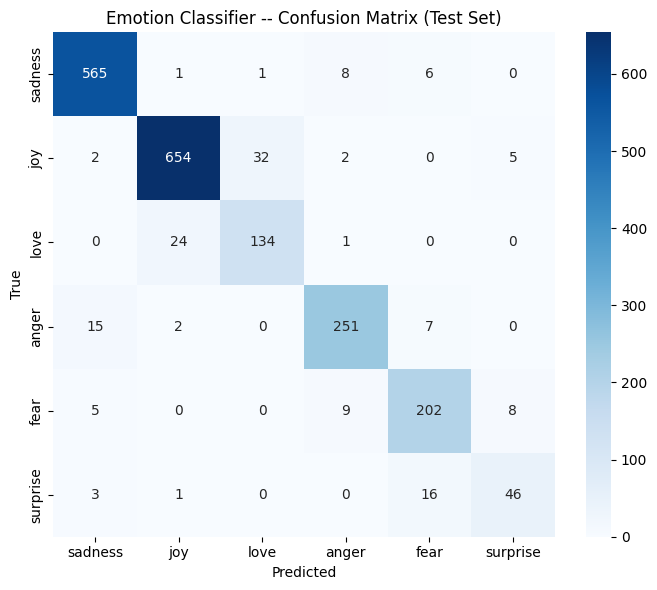

In [15]:
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm_em = confusion_matrix(test_labels_em, all_preds_em)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_em, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Emotion Classifier -- Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("emotion_confusion_matrix.png", dpi=150)
plt.show()

In [16]:
# Demonstrate inference on new sentences
test_sentences = [
    "I cannot believe how wonderful today has been.",
    "She betrayed my trust completely and I am furious.",
    "I am terrified of what might happen next.",
    "This is the saddest story I have ever read.",
    "I am so grateful for everything you have done.",
    "I had absolutely no idea this was coming -- completely shocked.",
]

print(f"{'Sentence':<55}  Prediction   Confidence")
print("-" * 85)
for s in test_sentences:
    result = emotion_pipe(s, truncation=True, max_length=64)[0]
    lid    = int(result["label"].split("_")[1])
    print(f"{s:<55}  {label_names[lid]:<12} {result['score']:.3f}")


Sentence                                                 Prediction   Confidence
-------------------------------------------------------------------------------------
I cannot believe how wonderful today has been.           joy          0.997
She betrayed my trust completely and I am furious.       anger        0.996
I am terrified of what might happen next.                fear         0.996
This is the saddest story I have ever read.              sadness      0.997
I am so grateful for everything you have done.           joy          0.991
I had absolutely no idea this was coming -- completely shocked.  surprise     0.990
